In [67]:
#Basic libraries
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import math
pd.set_option('display.max_columns', None)
plt.style.use('ggplot')
from datetime import datetime as dt

#Sampling methods
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

#feature engineering
import datetime as dt
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score
from imblearn.over_sampling import SMOTE

#Feature Selection
from boruta import BorutaPy

#Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report

#Hyperparameter tuning
from skopt import gp_minimize
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

#Model evaluation
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import classification_report
from sklearn import metrics
import scipy.stats as stats
from scipy.stats import skew

In [2]:
df = pd.read_csv('fraudTest.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
dftest = pd.read_csv('fraudTrain.csv')
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [4]:
print(df.shape[0])

555719


In [5]:
print(dftest.shape[0])

1296675


In [6]:
fraud = df[df["is_fraud"] == 1]
not_fraud =  df[df["is_fraud"] == 0]
print(fraud.shape[0])
print(not_fraud.shape[0])

2145
553574


In [7]:
fraud = dftest[dftest["is_fraud"] == 1]
not_fraud =  dftest[dftest["is_fraud"] == 0]
print(fraud.shape[0])
print(not_fraud.shape[0])

7506
1289169


In [8]:
#checking the null values in the data 
df.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

In [9]:
#checking the null values in the data 
dftest.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [11]:
df.isna().sum().sum()

0

In [12]:
dftest.isna().sum().sum()

0

In [13]:
df.duplicated().any()

False

In [14]:
dftest.duplicated().any()

False

In [14]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


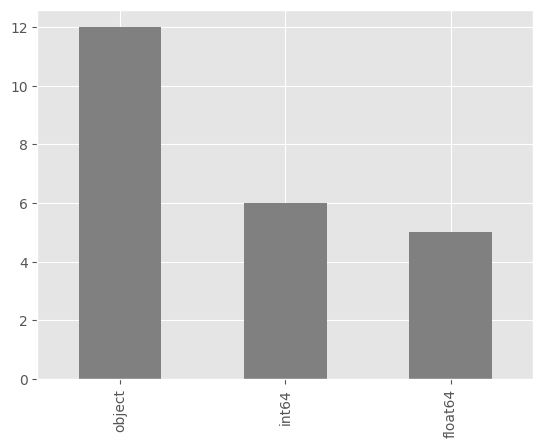

In [16]:
df.dtypes.value_counts().plot(kind='bar', color="grey");

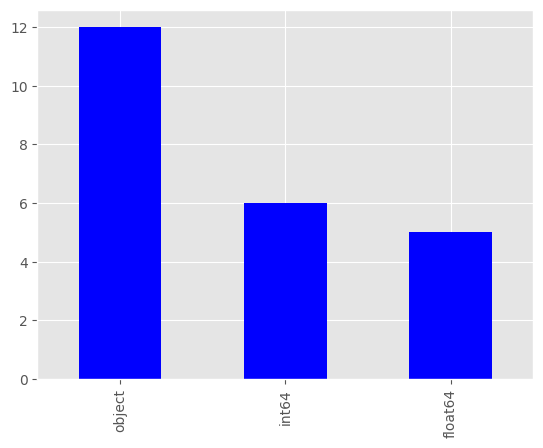

In [17]:
dftest.dtypes.value_counts().plot(kind='bar', color="blue");

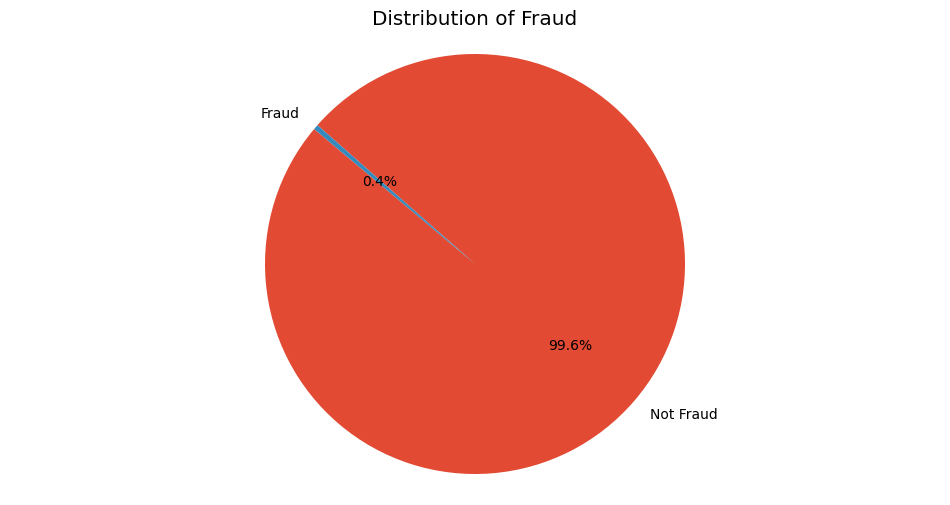

In [18]:
plt.figure(figsize = (12,6))
labels = ["Not Fraud","Fraud"]
values = df.is_fraud.value_counts()
plt.pie(values,labels = labels,autopct = "%1.1f%%",startangle = 140)
plt.title("Distribution of Fraud")
plt.axis("equal")
plt.show()

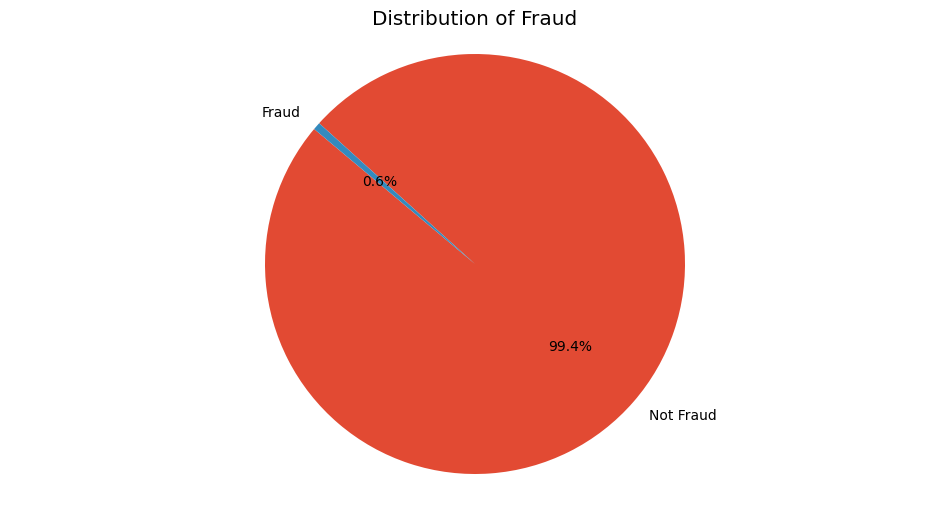

In [19]:
plt.figure(figsize = (12,6))
labels = ["Not Fraud","Fraud"]
values = dftest.is_fraud.value_counts()
plt.pie(values,labels = labels,autopct = "%1.1f%%",startangle = 140)
plt.title("Distribution of Fraud")
plt.axis("equal")
plt.show()

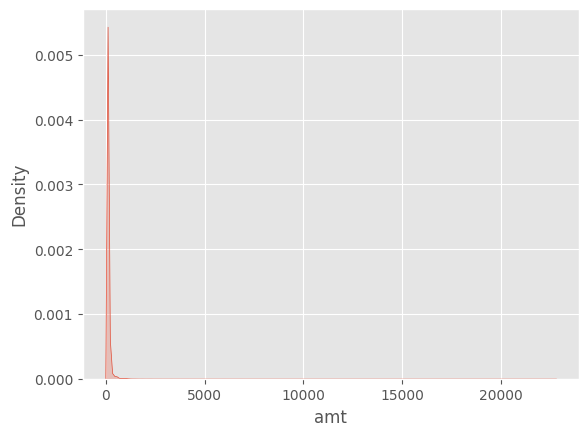

In [20]:
sns.kdeplot(df["amt"], fill=True);

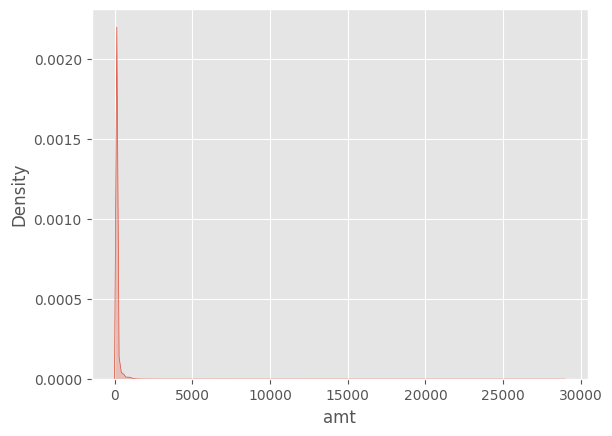

In [21]:
sns.kdeplot(dftest["amt"], fill=True);

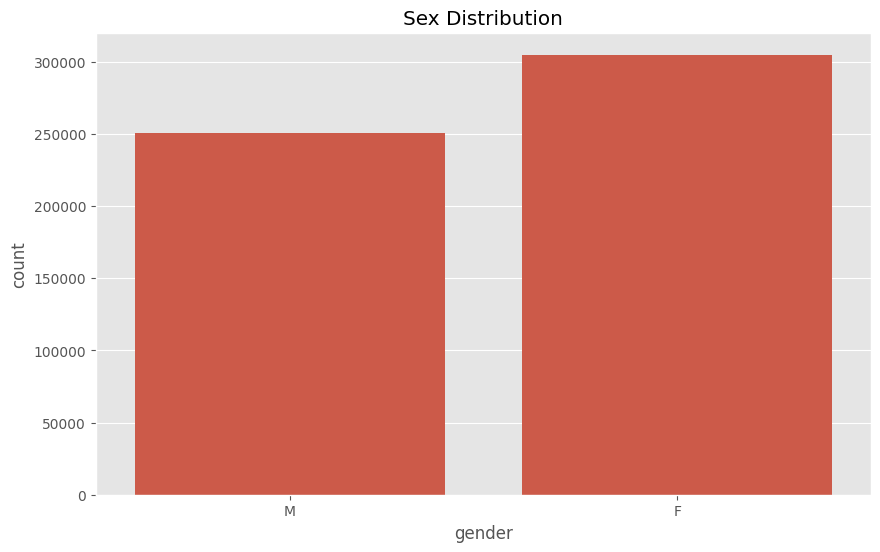

In [22]:
# Count plot for categorical features [categorical visualization]
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=df)
plt.title('Sex Distribution')
plt.show()

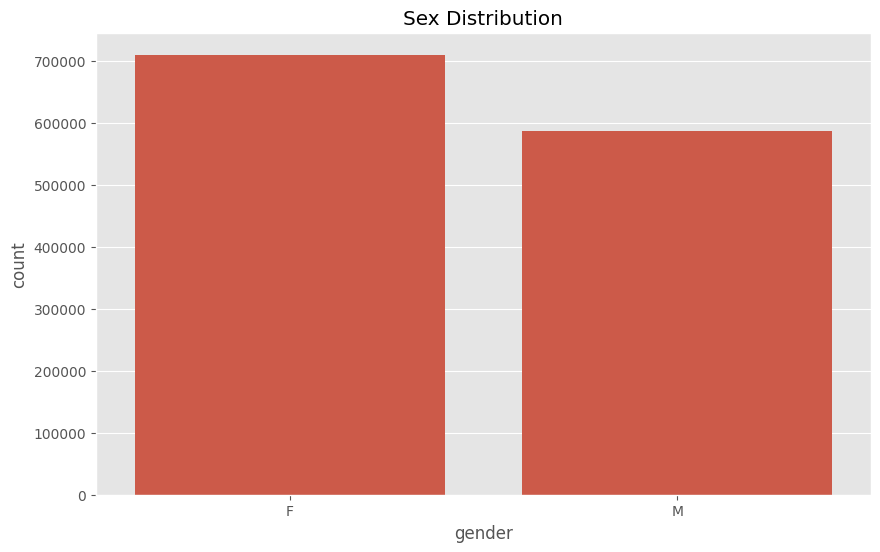

In [24]:
# Count plot for categorical features [categorical visualization]
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=dftest)
plt.title('Sex Distribution')
plt.show()

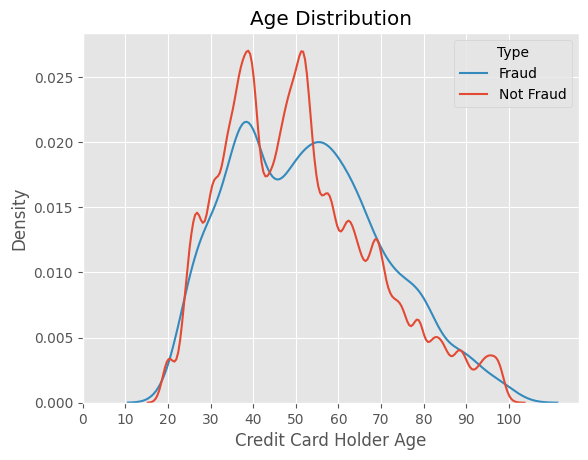

In [23]:
from datetime import datetime as dt
# Assuming df is your DataFrame and it contains a 'dob' column
df['age'] = dt.today().year - pd.to_datetime(df['dob']).dt.year

# Plotting the KDE plot
ax = sns.kdeplot(x='age', data=df, hue='is_fraud', common_norm=False)
ax.set_xlabel('Credit Card Holder Age')
ax.set_ylabel('Density')
plt.xticks(np.arange(0, 110, 10))
plt.title('Age Distribution')
plt.legend(title='Type', labels=['Fraud', 'Not Fraud'])

plt.show()

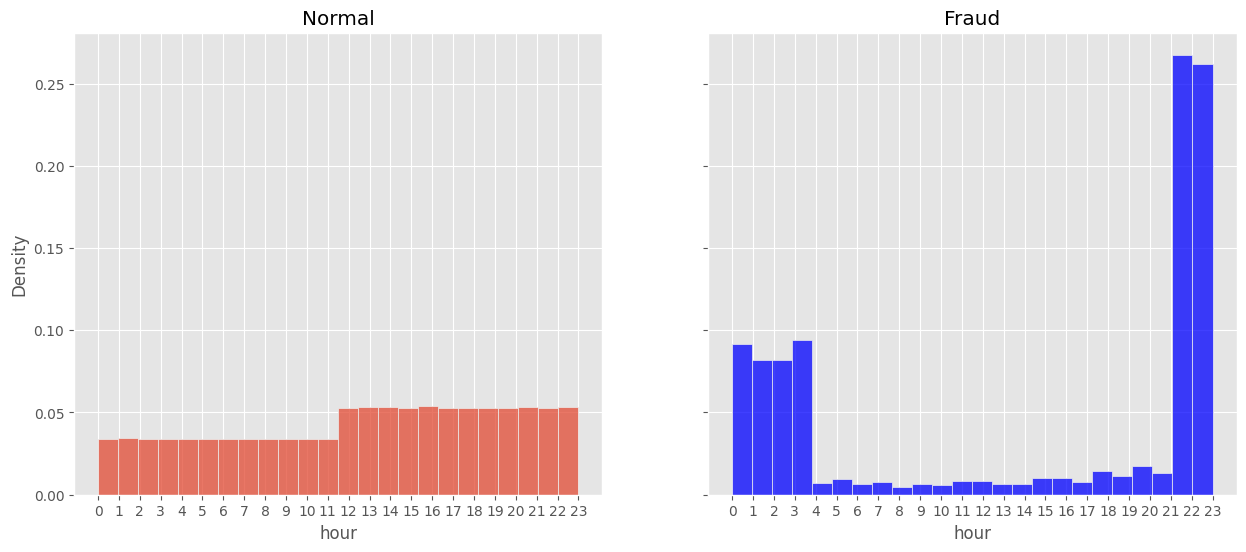

In [24]:
# Assuming df is your DataFrame and it contains a 'trans_date_trans_time' column
df['hour'] = pd.to_datetime(df['trans_date_trans_time']).dt.hour

# Creating the subplots
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plotting the histograms
ax1 = sns.histplot(x='hour', data=df[df["is_fraud"] == 0], stat="density", bins=24, ax=ax1)
ax2 = sns.histplot(x='hour', data=df[df["is_fraud"] == 1], stat="density", bins=24, ax=ax2, color="blue")

# Setting titles and x-ticks
ax1.set_title("Normal")
ax2.set_title("Fraud")
ax1.set_xticks(np.arange(0, 24))
ax2.set_xticks(np.arange(0, 24))

plt.show()

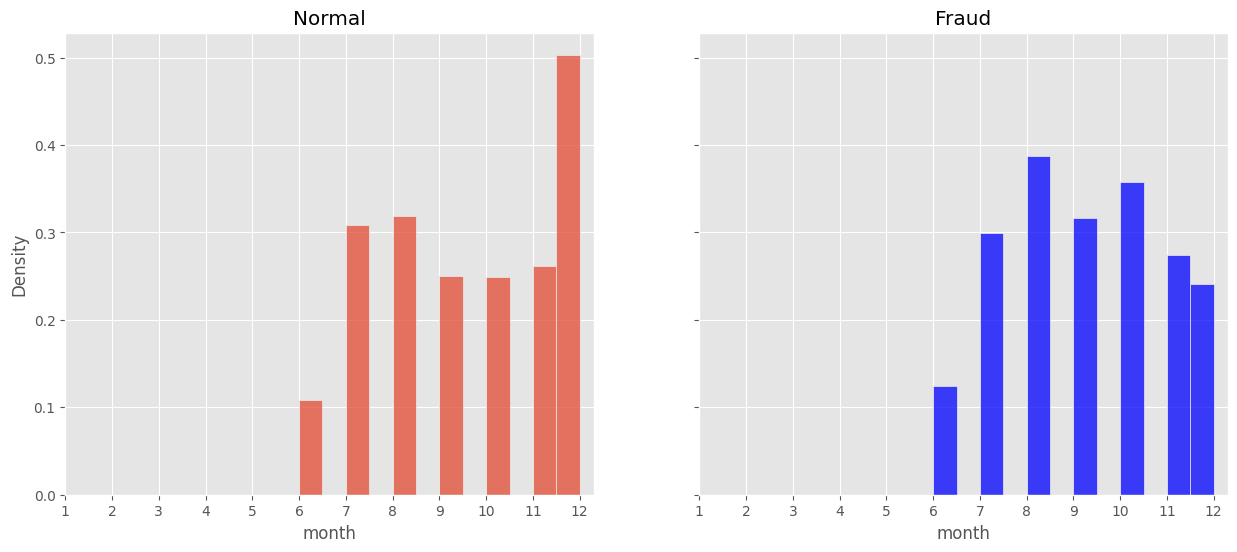

In [25]:
# Assuming df is your DataFrame and it contains a 'trans_date_trans_time' column
df['month'] = pd.to_datetime(df['trans_date_trans_time']).dt.month

# Creating the subplots
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plotting the histograms
ax1 = sns.histplot(x='month', data=df[df["is_fraud"] == 0], stat="density", bins=12, ax=ax1)
ax2 = sns.histplot(x='month', data=df[df["is_fraud"] == 1], stat="density", bins=12, ax=ax2, color="blue")

# Setting titles and x-ticks
ax1.set_title("Normal")
ax2.set_title("Fraud")
ax1.set_xticks(np.arange(1, 13))
ax2.set_xticks(np.arange(1, 13))

plt.show()

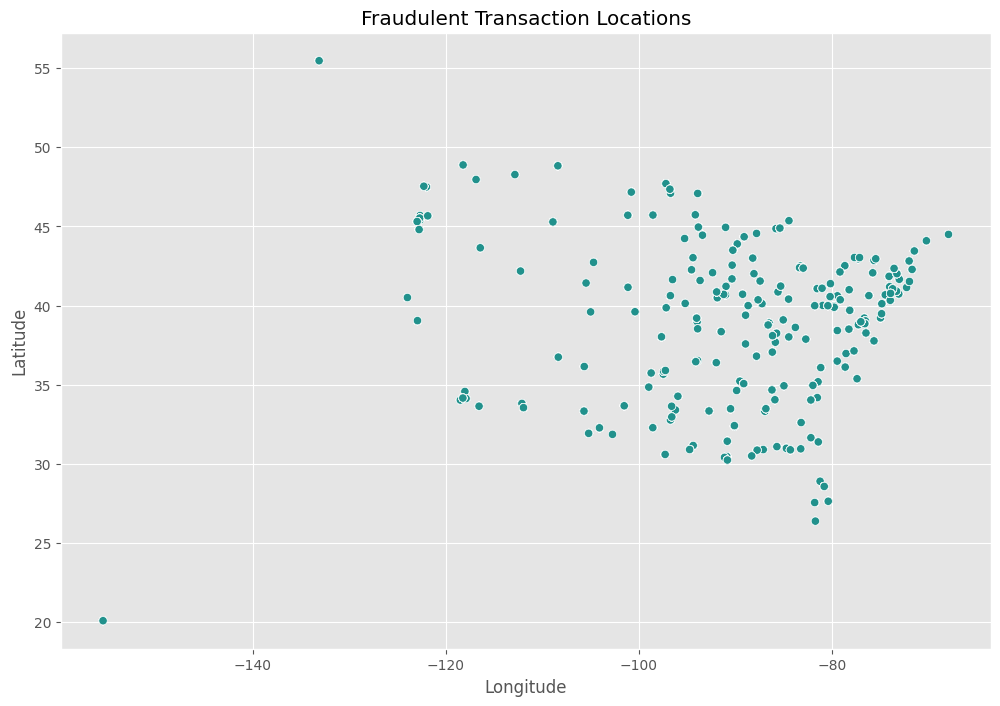

In [26]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df[df['is_fraud'] == 1], x='long', y='lat', hue='is_fraud', palette='viridis', legend=False)
plt.title('Fraudulent Transaction Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

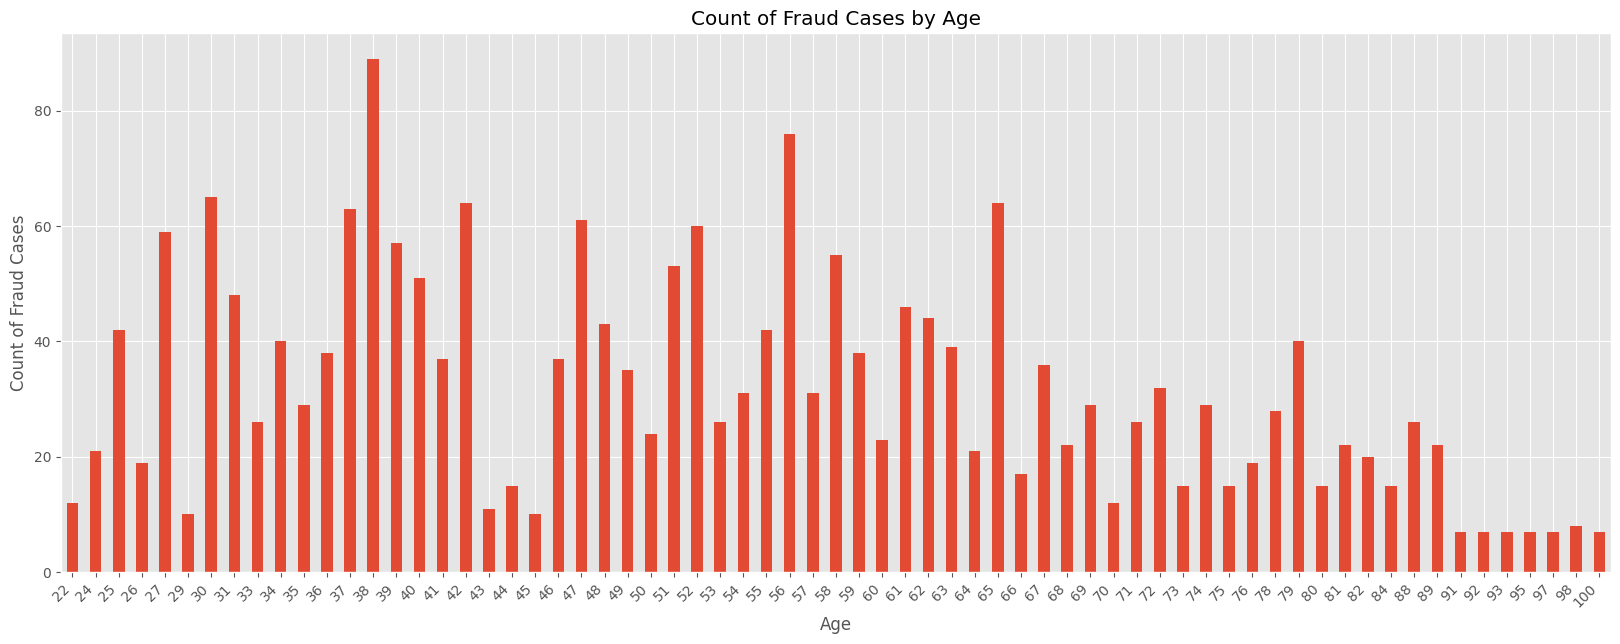

In [27]:
plt.figure(figsize=(20, 7))
ax = df[df['is_fraud'] == 1].groupby('age').count()['is_fraud'].plot(kind='bar')
ax.set_xlabel('Age')
ax.set_ylabel('Count of Fraud Cases')
ax.set_title('Count of Fraud Cases by Age')
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='is_fraud'>

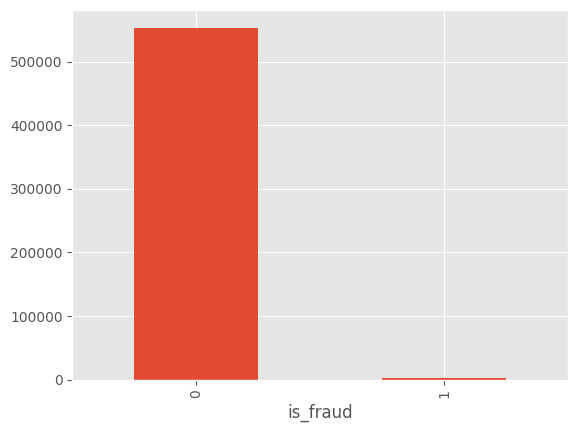

In [28]:
df.groupby("is_fraud").count()['cc_num'].plot(kind = "bar")


<Axes: xlabel='is_fraud'>

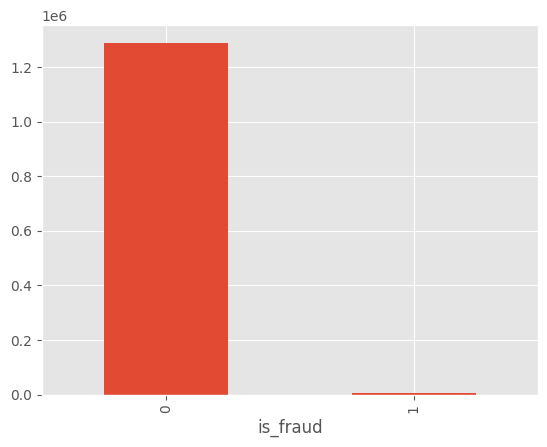

In [29]:
dftest.groupby("is_fraud").count()['cc_num'].plot(kind = "bar")


In [ ]:
#Feature Engineering 

In [15]:
df["dob"] = pd.to_datetime(df["dob"])

In [16]:
dftest["dob"] = pd.to_datetime(dftest["dob"])

In [17]:
# Convert the 'dob' column to datetime format
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

# Extract the year from the 'dob' column
df["dob"] = df["dob"].dt.year

# Calculate the age by subtracting the birth year from the current year
df['dob'] = datetime.now().year - df['dob']

# Rename the 'dob' column to 'age'
df = df.rename(columns={"dob": "age"})

# Display the DataFrame
df

NameError: name 'datetime' is not defined

In [18]:
numeric_columns = df.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

In [20]:
print(numeric_columns)
print(categorical_columns)

['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'trans_num']


In [21]:
encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2291163933867244,319,10,2.86,151,115,1,341,157,39,29209,33.9659,-80.9355,333497,275,1968,98699,1371816865,33.986391,-81.200714,0
1,1,1,3573030041201292,591,10,29.84,163,457,0,354,16,43,84002,40.3207,-110.4360,302,392,1990,108785,1371816873,39.450498,-109.960431,0
2,2,2,3598215285024754,611,5,41.28,24,249,0,865,61,33,11710,40.6729,-73.5365,34496,259,1970,433979,1371816893,40.495810,-74.196111,0
3,3,3,3591919803438423,222,9,60.05,42,457,1,320,764,8,32780,28.5697,-80.8191,54767,407,1987,71993,1371816915,28.812398,-80.883061,0
4,4,4,3526826139003047,292,13,3.19,247,261,1,548,247,21,49632,44.2529,-85.0170,1126,196,1955,190585,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,544755,30560609640617,507,5,43.77,235,315,1,531,443,23,63453,40.4931,-91.8912,519,460,1966,336391,1388534347,39.946837,-91.333331,0
555715,555715,544756,3556613125071656,264,7,111.84,171,424,1,540,401,42,77566,29.0393,-95.4401,28739,198,1999,70372,1388534349,29.661049,-96.186633,0
555716,555716,544757,6011724471098086,496,7,86.88,18,239,0,126,104,46,99323,46.1966,-118.9017,3684,294,1981,235088,1388534355,46.658340,-119.715054,0
555717,555717,544758,4079773899158,75,13,7.99,111,342,1,663,476,12,83643,44.6255,-116.4493,129,58,1965,43546,1388534364,44.470525,-117.080888,0


In [22]:
# Initialize the models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
}

In [23]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:21]

y_train=df.iloc[:,22]

X_test=dftest


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [24]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [25]:
from sklearn.tree import DecisionTreeClassifier  
classifier= DecisionTreeClassifier(criterion='entropy', random_state=0)  
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [28]:
y_pred= classifier.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
mae

0.0028431584251061687

In [30]:
score=r2_score(y_test,y_pred)
score

0.24714602249464124

In [32]:
#conf_matrix = confusion_matrix(y_test, y_pred)
#print('Confusion Matrix:')
#print(conf_matrix)
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166084
           1       0.63      0.61      0.62       632

    accuracy                           1.00    166716
   macro avg       0.81      0.80      0.81    166716
weighted avg       1.00      1.00      1.00    166716



In [33]:
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2291163933867244,319,10,2.86,151,115,1,341,157,39,29209,33.9659,-80.9355,333497,275,1968,98699,1371816865,33.986391,-81.200714,0
1,1,1,3573030041201292,591,10,29.84,163,457,0,354,16,43,84002,40.3207,-110.4360,302,392,1990,108785,1371816873,39.450498,-109.960431,0
2,2,2,3598215285024754,611,5,41.28,24,249,0,865,61,33,11710,40.6729,-73.5365,34496,259,1970,433979,1371816893,40.495810,-74.196111,0
3,3,3,3591919803438423,222,9,60.05,42,457,1,320,764,8,32780,28.5697,-80.8191,54767,407,1987,71993,1371816915,28.812398,-80.883061,0
4,4,4,3526826139003047,292,13,3.19,247,261,1,548,247,21,49632,44.2529,-85.0170,1126,196,1955,190585,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,544755,30560609640617,507,5,43.77,235,315,1,531,443,23,63453,40.4931,-91.8912,519,460,1966,336391,1388534347,39.946837,-91.333331,0
555715,555715,544756,3556613125071656,264,7,111.84,171,424,1,540,401,42,77566,29.0393,-95.4401,28739,198,1999,70372,1388534349,29.661049,-96.186633,0
555716,555716,544757,6011724471098086,496,7,86.88,18,239,0,126,104,46,99323,46.1966,-118.9017,3684,294,1981,235088,1388534355,46.658340,-119.715054,0
555717,555717,544758,4079773899158,75,13,7.99,111,342,1,663,476,12,83643,44.6255,-116.4493,129,58,1965,43546,1388534364,44.470525,-117.080888,0


In [34]:
rs = np.random.RandomState(0)

corr = df.corr().abs()
corr.style.background_gradient(cmap='coolwarm')
# 'RdBu_r', 'BrBG_r', & PuOr_r are other good diverging colormaps

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
Unnamed: 0,1.000000,0.999998,0.000823,0.000832,0.001480,0.001137,0.000940,0.001603,0.000480,0.000282,0.001773,0.000135,0.001479,0.000336,0.001558,0.000794,0.000555,0.002735,0.001368,0.997054,0.000394,0.001586,0.013892
trans_date_trans_time,0.999998,1.000000,0.000822,0.000839,0.001470,0.001132,0.000937,0.001605,0.000482,0.000284,0.001772,0.000133,0.001476,0.000334,0.001556,0.000793,0.000558,0.002731,0.001367,0.997205,0.000393,0.001583,0.013864
cc_num,0.000823,0.000822,1.000000,0.001326,0.001779,0.001963,0.030216,0.007260,0.001482,0.044153,0.049211,0.036721,0.041610,0.057512,0.048783,0.009414,0.031604,0.000203,0.000125,0.000810,0.057183,0.048818,0.001540
merchant,0.000832,0.000839,0.001326,1.000000,0.028033,0.003780,0.001027,0.000512,0.002018,0.000663,0.001737,0.000106,0.000290,0.000455,0.000466,0.000194,0.000713,0.003036,0.000028,0.001017,0.000743,0.000395,0.000086
category,0.001480,0.001470,0.001779,0.028033,1.000000,0.026811,0.002089,0.002702,0.027684,0.002538,0.001949,0.000169,0.004510,0.008215,0.002902,0.009164,0.001794,0.001888,0.001348,0.001097,0.008180,0.002967,0.016980
amt,0.001137,0.001132,0.001963,0.003780,0.026811,1.000000,0.000584,0.006236,0.000027,0.001114,0.000576,0.002561,0.002310,0.002339,0.002046,0.002760,0.004848,0.012865,0.002609,0.000974,0.002404,0.002053,0.182267
first,0.000940,0.000937,0.030216,0.001027,0.002089,0.000584,1.000000,0.058780,0.012469,0.049143,0.012116,0.044898,0.003594,0.130362,0.014595,0.067630,0.040966,0.005658,0.002572,0.000870,0.129213,0.014627,0.001725
last,0.001603,0.001605,0.007260,0.000512,0.002702,0.006236,0.058780,1.000000,0.042456,0.002867,0.020868,0.048490,0.030032,0.032045,0.027565,0.010603,0.022202,0.019861,0.002153,0.001591,0.031899,0.027526,0.001203
gender,0.000480,0.000482,0.001482,0.002018,0.027684,0.000027,0.012469,0.042456,1.000000,0.041903,0.016914,0.030149,0.066467,0.042692,0.051235,0.029367,0.079028,0.004505,0.000446,0.000577,0.042569,0.051203,0.000748
street,0.000282,0.000284,0.044153,0.000663,0.002538,0.001114,0.049143,0.002867,0.041903,1.000000,0.023860,0.014589,0.055484,0.013773,0.073951,0.011993,0.014808,0.038358,0.000099,0.000331,0.013682,0.073900,0.001943


In [37]:
corr_matrix = df.corr().abs()

In [39]:
# Select upper triangle of the correlation matrix
upper = corr.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


In [41]:
# Assuming your dataframe is named df and 'is_fraud' is the target column
X = df.drop(['is_fraud'], axis=1)  # Define X as your feature matrix

# Calculate the correlation matrix
corr_matrix = X.corr()

# Select upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find index of feature columns with correlation greater than 0.8
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

# Drop highly correlated features
X.drop(to_drop, axis=1, inplace=True)

# Now X is updated, and you can print it or continue with further processing
print(X)


        Unnamed: 0            cc_num  merchant  category     amt  first  last  \
0                0  2291163933867244       319        10    2.86    151   115   
1                1  3573030041201292       591        10   29.84    163   457   
2                2  3598215285024754       611         5   41.28     24   249   
3                3  3591919803438423       222         9   60.05     42   457   
4                4  3526826139003047       292        13    3.19    247   261   
...            ...               ...       ...       ...     ...    ...   ...   
555714      555714    30560609640617       507         5   43.77    235   315   
555715      555715  3556613125071656       264         7  111.84    171   424   
555716      555716  6011724471098086       496         7   86.88     18   239   
555717      555717     4079773899158        75        13    7.99    111   342   
555718      555718  4170689372027579       125         0   38.13    280   145   

        gender  street  cit

In [42]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2291163933867244,319,10,2.86,151,115,1,341,157,39,29209,33.9659,-80.9355,333497,275,1968,98699,1371816865,33.986391,-81.200714,0
1,1,1,3573030041201292,591,10,29.84,163,457,0,354,16,43,84002,40.3207,-110.4360,302,392,1990,108785,1371816873,39.450498,-109.960431,0
2,2,2,3598215285024754,611,5,41.28,24,249,0,865,61,33,11710,40.6729,-73.5365,34496,259,1970,433979,1371816893,40.495810,-74.196111,0
3,3,3,3591919803438423,222,9,60.05,42,457,1,320,764,8,32780,28.5697,-80.8191,54767,407,1987,71993,1371816915,28.812398,-80.883061,0
4,4,4,3526826139003047,292,13,3.19,247,261,1,548,247,21,49632,44.2529,-85.0170,1126,196,1955,190585,1371816917,44.959148,-85.884734,0


In [45]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:21]

y_train=df.iloc[:,22]

X_test=dftest


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [46]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [47]:
from sklearn.tree import DecisionTreeClassifier  
classifier= DecisionTreeClassifier(criterion='entropy', random_state=0)  
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [48]:
y_pred= classifier.predict(X_test)

In [49]:
#conf_matrix = confusion_matrix(y_test, y_pred)
#print('Confusion Matrix:')
#print(conf_matrix)
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    166085
           1       0.01      0.19      0.02       631

    accuracy                           0.93    166716
   macro avg       0.50      0.56      0.49    166716
weighted avg       0.99      0.93      0.96    166716



In [52]:
columns = df.columns.tolist() 
columns.remove('is_fraud')


In [53]:

X = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']

X = df.drop(['is_fraud'], axis=1)
y = df['is_fraud']


scaler = StandardScaler()

X[columns] = scaler.fit_transform(X[columns])
df[X.columns] = X
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,-1.732048,-1.732669,-0.317252,-0.119663,0.961683,-0.424463,-0.232273,-0.994479,1.102494,-0.450296,-1.083619,0.937072,-0.731091,-0.904377,0.677451,0.816521,0.243860,-0.307935,-1.116803,-1.703871,-0.894145,0.657586,0
1,-1.732041,-1.732663,-0.316273,1.231656,0.961683,-0.252337,-0.106449,1.568286,-0.907034,-0.401053,-1.659570,1.220424,1.309217,0.351182,-1.472454,-0.292685,1.102086,0.955089,-1.053931,-1.703869,0.178126,-1.436610,0
2,-1.732035,-1.732656,-0.316254,1.331017,-0.316151,-0.179353,-1.563901,0.009646,-0.907034,1.534597,-1.475756,0.512044,-1.382695,0.420768,1.216667,-0.178853,0.126496,-0.193114,0.973182,-1.703865,0.383257,1.167640,0
3,-1.732029,-1.732650,-0.316259,-0.601568,0.706116,-0.059605,-1.375166,1.568286,1.102494,-0.529843,1.395827,-1.258908,-0.598119,-1.970539,0.685934,-0.111371,1.212115,0.782859,-1.283276,-1.703861,-1.909485,0.680717,0
4,-1.732023,-1.732644,-0.316308,-0.253802,1.728384,-0.422358,0.774312,0.099567,1.102494,0.333812,-0.715991,-0.338013,0.029394,1.128092,0.380004,-0.289942,-0.335625,-1.054267,-0.544027,-1.703861,1.259139,0.316510,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,1.732023,1.725931,-0.318978,0.814337,-0.316151,-0.163467,0.648489,0.504214,1.102494,0.269417,0.084621,-0.196337,0.544041,0.385244,-0.120967,-0.291963,1.600884,-0.422755,0.364862,1.510350,0.275527,-0.080241,0
555715,1.732029,1.725937,-0.316286,-0.392908,0.194983,0.270803,-0.022567,1.321002,1.102494,0.303509,-0.086939,1.149586,1.069562,-1.877757,-0.379599,-0.198018,-0.320955,1.471781,-1.293380,1.510351,-1.742946,-0.433644,0
555716,1.732035,1.725944,-0.314411,0.759688,0.194983,0.111564,-1.626812,-0.065289,-0.907034,-1.264708,-1.300111,1.432939,1.879720,1.512121,-2.089408,-0.281427,0.383230,0.438398,-0.266615,1.510352,1.592587,-2.146912,0
555717,1.732041,1.725950,-0.318998,-1.331876,1.728384,-0.391735,-0.651683,0.706538,1.102494,0.769428,0.219418,-0.975555,1.295849,1.201709,-1.910685,-0.293261,-1.347891,-0.480165,-1.460602,1.510354,1.163252,-1.955100,0


In [54]:
# Assuming X is a DataFrame with datetime columns
# Remove datetime columns if they are not needed for modeling
#X = X.drop(columns=['dob'])  # Corrected syntax: drop(columns=['column_name'])

# Create RandomForestClassifier model
model_rfc = RandomForestClassifier(random_state=42, n_estimators=10, n_jobs=-1, max_depth=20)

# Fit the model
model_rfc.fit(X, y)


RandomForestClassifier(max_depth=20, n_estimators=10, n_jobs=-1,
                       random_state=42)

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Assuming X is your feature matrix and y is your target variable
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# If you need to drop any columns, drop them from both X_train and X_test
# X_train = X_train.drop(columns=['dob'])
# X_test = X_test.drop(columns=['dob'])

# Create RandomForestClassifier model
model_rfc = RandomForestClassifier(random_state=42, n_estimators=10, n_jobs=-1, max_depth=20)

# Fit the model
model_rfc.fit(X_train, y_train)

# Predict using the test set
y_pred = model_rfc.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f'Accuracy Score: {accuracy}')

# Generate and print the classification report
report = classification_report(y_test, y_pred)
print('Classification Report:')
print(report)


Accuracy Score: 0.9982365219894911
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110718
           1       0.94      0.58      0.72       426

    accuracy                           1.00    111144
   macro avg       0.97      0.79      0.86    111144
weighted avg       1.00      1.00      1.00    111144



In [64]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Assuming X is your feature matrix and y is your target variable
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# If you need to drop any columns, drop them from both X_train and X_test
# X_train = X_train.drop(columns=['dob'])
# X_test = X_test.drop(columns=['dob'])

# Create RandomForestClassifier model
model_rfc = RandomForestClassifier(random_state=42, n_estimators=10, n_jobs=-1, max_depth=20)

# Fit the model
model_rfc.fit(X_train, y_train)

# Predict using the test set
y_pred = model_rfc.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f'Accuracy Score: {accuracy}')

# Generate and print the classification report
report = classification_report(y_test, y_pred)
print('Classification Report:')
print(report)


Accuracy Score: 0.9982365219894911
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110718
           1       0.94      0.58      0.72       426

    accuracy                           1.00    111144
   macro avg       0.97      0.79      0.86    111144
weighted avg       1.00      1.00      1.00    111144



In [68]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]}


In [69]:
model_rfc = RandomForestClassifier(random_state=42, n_estimators=10, n_jobs=-1, max_depth=20)


In [70]:
grid_search = GridSearchCV(estimator=model_rfc, param_grid=param_grid, 
                           cv=2, n_jobs=-1, verbose=2)

grid_search.fit(X, y)

Fitting 2 folds for each of 216 candidates, totalling 432 fits


GridSearchCV(cv=2,
             estimator=RandomForestClassifier(max_depth=20, n_estimators=10,
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [71]:
y_pred = grid_search.predict(X_test)

# Calculate the accuracy score
accuracy = accuracy_score(y_test, y_pred)

# Print the accuracy score
print(f'Accuracy Score: {accuracy}')

Accuracy Score: 1.0


In [72]:
# Print the best parameters and the best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.500066573349759


In [73]:
scores = cross_val_score(model_rfc, X, y, cv=5)

# Print the cross-validation scores and the mean score
print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {scores.mean()}")

Cross-validation scores: [0.99676996 0.99689592 0.32343626 0.36180091 0.99614011]
Mean cross-validation score: 0.7350086304975667


In [76]:

print('Cross-Validation Classification Report:')

Cross-Validation Classification Report:


In [77]:
print('Cross-Validation Classification Report:')
print(report)

Cross-Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110718
           1       0.94      0.58      0.72       426

    accuracy                           1.00    111144
   macro avg       0.97      0.79      0.86    111144
weighted avg       1.00      1.00      1.00    111144

